# Arbitrary rotation $U_R\in SU(2)$ in MBQC
on a five-qubit linear cluster

## References
- _A One-Way Quantum Computer_, Raussendorf R. and Briegel H.J., Phys. Rev. Lett., 86, 22, 5188-5191, 2001, American Physical Society, [DOI](https://link.aps.org/doi/10.1103/PhysRevLett.86.5188)
- *Measurement-based quantum computation on cluster states*, Raussendorf R. , Browne D. E. and Briegel H. J., **Physical Review A**, 68, 022312, 2003, [DOI](https://link.aps.org/doi/10.1103/PhysRevA.68.022312).

## Environment setup

The following cells install the dependencies and set the working directory to the folder containing this notebook. You may need to restart the kernel after installing the dependencies.

On Google Colab, setup clones the repository (`main` branch) and selects the example directory before installing dependencies. If prompted, restart the runtime and rerun the cells. The clone is reused within the same session; start a fresh Colab session to fetch updates from GitHub.


In [ ]:
from pathlib import Path
import os
import subprocess

try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    repository = Path("/content/mbqc-codes")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/AlbertoMiserendino/mbqc-codes.git",
            str(repository),
        ], check=True)
    os.chdir(repository / "02-mbqc-rotation")

%pip install -r "../requirements.txt" -q
# If prompted, restart the runtime/kernel and run the cells again.


In [2]:
from pathlib import Path
import os
import ipynbname

# Automated runs already start in the notebook directory.
if not Path("mbqc-rotation.qasm").is_file():
    os.chdir(ipynbname.path().parent)


/home/alberto/qc/02-mbqc-rotation


## Arbitrary rotation on a linear cluster

Consider the five-qubit linear cluster

$$
q_0-q_1-q_2-q_3-q_4,
$$

where $q_0$ holds the input state and $q_4$ is the output qubit.

To make the final verification nontrivial and without loss of generality, we prepare the initial state as

$$
|\psi_{\mathrm{in}}\rangle
=
R_z(\phi)R_y(\theta)|0\rangle.
$$

The operation to implement is an arbitrary $SU(2)$ rotation. Using the $XZX$ Euler decomposition, we write it as

$$
U_R(\xi,\eta,\zeta)
=
R_x(\zeta)R_z(\eta)R_x(\xi),
$$

where

$$
R_x(\alpha)=e^{-i\alpha X/2},
\qquad
R_z(\alpha)=e^{-i\alpha Z/2}.
$$

The qubits $q_1,\ldots,q_4$ are initialized in $|+\rangle$ and the cluster connections are implemented using $CZ$ gates.

$$
\left|\psi_{\mathrm{in}}\right\rangle_5
=
\left|\psi_{\mathrm{in}}\right\rangle_0
\otimes
\left(
\bigotimes_{i=1}^{4} |+\rangle_i
\right)\qquad\overset{S^{(\mathcal C_5)}}{\longmapsto}\qquad S^{(\mathcal C_5)} \left|\psi_{\mathrm{in}}\right\rangle_5
$$

Measuring the first four qubits teleports the state to $q_4$ while implementing $U_R$.

## Adaptive measurement bases

Each qubit $j$ is measured in an appropriate equatorial basis:

$$
\mathcal B_j(\alpha_j)
=
\left\{
\frac{|0\rangle+e^{i\alpha_j}|1\rangle}{\sqrt2},
\frac{|0\rangle-e^{i\alpha_j}|1\rangle}{\sqrt2}
\right\}.
$$

With this definition, a measurement in $\mathcal B_j(\alpha_j)$ can be implemented by applying $R_z(-\alpha_j)$, followed by $H$ and then measuring in the computational basis. Indeed, $R_z(-\alpha)$ removes the relative phase $e^{i\alpha}$, mapping $\{|\!+_\alpha\rangle,|\!-_\alpha\rangle\}$ to the $X$ basis; $H$ then maps $X$ to $Z$.

The implementation follows the explicit convention in the detailed derivation by Raussendorf, Browne and Briegel (2003):

$$
\begin{aligned}
\alpha_1 &= 0,\\
\alpha_2 &= -(-1)^{s_1}\xi
          =(-1)^{s_1+1}\xi,\\
\alpha_3 &= -(-1)^{s_2}\eta
          =(-1)^{s_2+1}\eta,\\
\alpha_4 &= -(-1)^{s_1+s_3}\zeta
          =(-1)^{s_1+s_3+1}\zeta.
\end{aligned}
$$

The outcomes $s_j\in\{0,1\}$ therefore determine the signs of subsequent measurement angles: this classical dependency is the **feed-forward** characteristic of MBQC.

> **Note on signs.** The excerpt from the 2001 paper presents an abbreviated procedure. The signs in the OpenQASM circuit below are consistent with the explicit definition of $\mathcal B(\alpha)$, the convention $R_z(\alpha)=e^{-i\alpha Z/2}$ and the detailed 2003 procedure.

## Pauli byproduct correction

After the four measurements, before correction, the output qubit is *rotated* as follows:

$$
|\psi'_{\mathrm{out}}\rangle
=
\underbrace{X^{s_2\oplus s_4}Z^{s_1\oplus s_3}}_{\equiv U_\Sigma}\;
%
U_R(\xi,\eta,\zeta)\;
%
|\psi_{\mathrm{in}}\rangle.
$$

The factor $U_\Sigma$ is a *Pauli byproduct*: it depends on the random measurement outcomes and accompanies the intended logical operation. We can remove it at the end of the computation by applying its inverse:

$$
U_\Sigma^{-1}
=
Z^{s_1\oplus s_3}X^{s_2\oplus s_4}.
$$

## OpenQASM circuit

The OpenQASM file contains the input state preparation, cluster creation, four adaptive measurements and final corrections on qubit $q_4$.

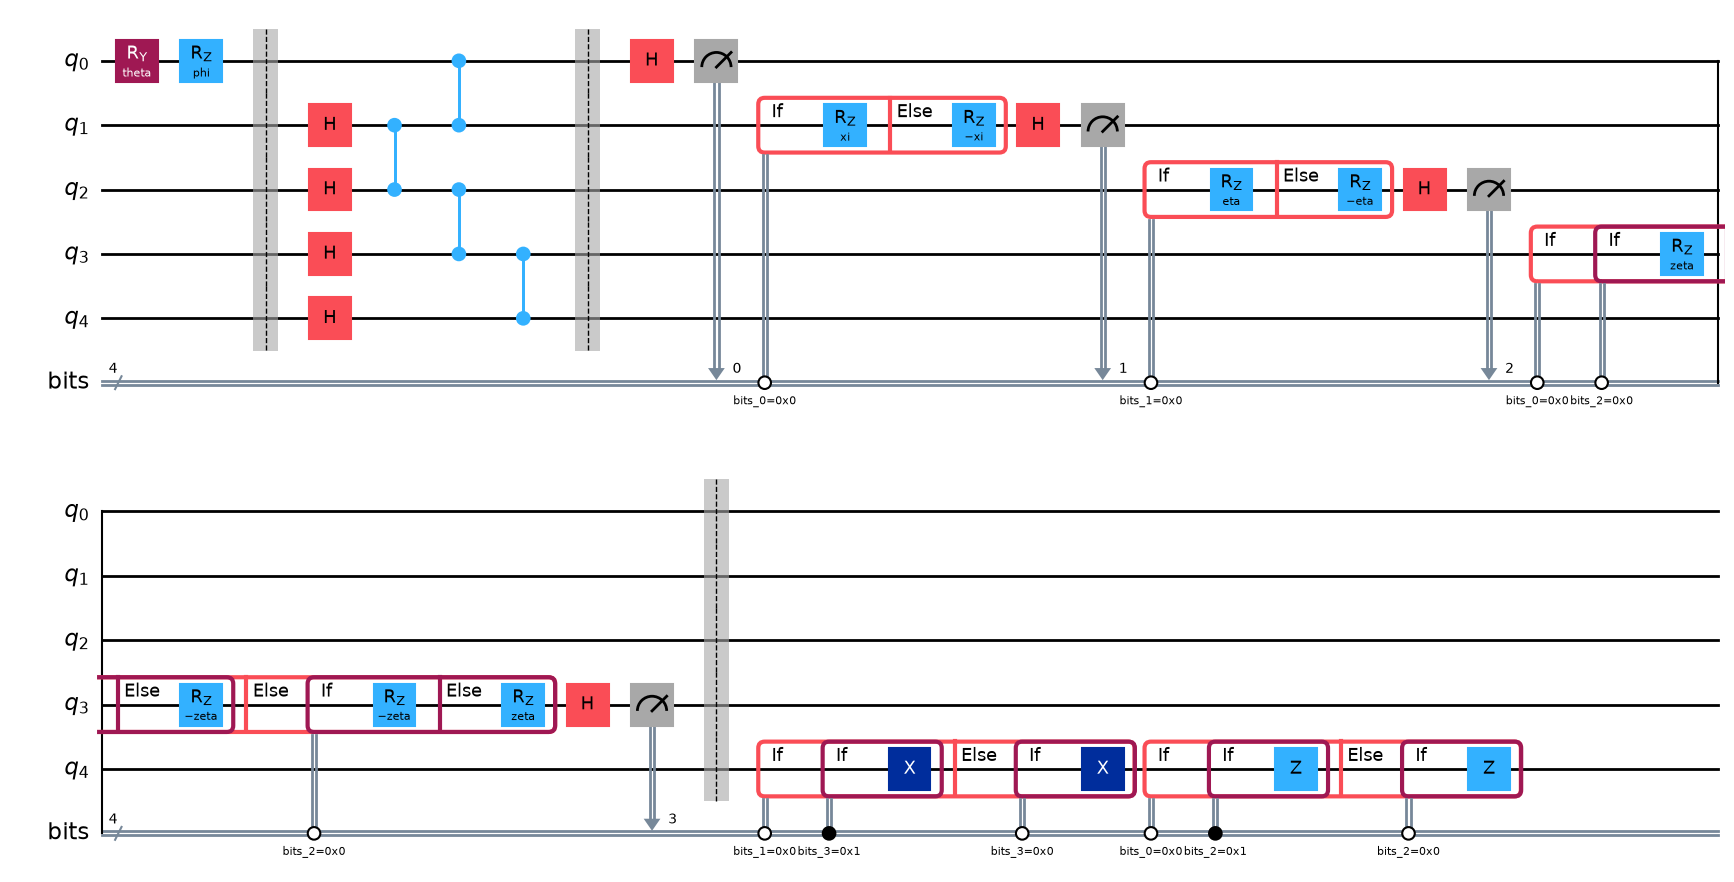

In [3]:
from qiskit import qasm3

# Load the dynamic MBQC circuit described in OpenQASM 3.
qc = qasm3.load("./mbqc-rotation.qasm")

# Display the full circuit; fold limits the drawing width.
qc.draw("mpl", fold=25)

## Numerical parameters

The circuit has five parameters:

- $\theta,\phi$ prepare the arbitrary input state;
- $\xi,\eta,\zeta$ define the rotation $U_R$.

We choose generic values so that the verification involves all components of the Bloch vector.

In [4]:
# Show the symbolic parameters imported from the OpenQASM file.
print("Number of parameters:", qc.num_parameters)
print("Parameters:", qc.parameters)

Number of parameters: 5
Parameters: ParameterView([Parameter(eta), Parameter(phi), Parameter(theta), Parameter(xi), Parameter(zeta)])


In [5]:
import numpy as np

# Map names to Parameter objects for binding by name.
params = {p.name: p for p in qc.parameters}

# Input state |psi_in> = Rz(phi) Ry(theta) |0>.
theta_value = np.pi / 3
phi_value = np.pi / 5

# Euler angles of the rotation U_R = Rx(zeta) Rz(eta) Rx(xi).
xi_value = np.pi / 4
eta_value = -np.pi / 6
zeta_value = np.pi / 3

# Replace all symbolic parameters with numerical values.
qc_bound = qc.assign_parameters({
    params["theta"]: theta_value,
    params["phi"]: phi_value,
    params["xi"]: xi_value,
    params["eta"]: eta_value,
    params["zeta"]: zeta_value,
})

print("Remaining parameters:", qc_bound.parameters)

Remaining parameters: ParameterView([])


## Output qubit verification

After feed-forward and corrections, the logical state resides on $q_4$. We can reconstruct the Bloch vector by estimating

$$
\langle X\rangle,\qquad
\langle Y\rangle,\qquad
\langle Z\rangle\;.
$$

Thus, $\vec{r} = \left(\langle X\rangle,\langle Y\rangle,\langle Z\rangle\right)$.

To avoid overwriting the four classical bits $s_1,\ldots,s_4$, each circuit copy receives a new classical register `out` dedicated to the final measurement.

The basis changes before computational-basis measurement are

$$
M_X=M_ZH,
\qquad
M_Y=M_ZHS^\dagger,
\qquad
M_Z=M_Z.
$$

In [6]:
from qiskit import ClassicalRegister

# The output qubit is q[4].
OUTPUT_QUBIT = 4

def circuit_for_pauli_measurement(circuit, basis):
    """Return a circuit copy with q[4] measured in X, Y, or Z."""
    measured = circuit.copy()

    # Dedicated register for the output measurement (one bit).
    out = ClassicalRegister(1, f"out_{basis.lower()}")
    measured.add_register(out)

    # Change basis before the Z measurement.
    if basis == "X":
        measured.h(OUTPUT_QUBIT)
    elif basis == "Y":
        measured.sdg(OUTPUT_QUBIT)
        measured.h(OUTPUT_QUBIT)
    elif basis != "Z":
        raise ValueError("basis must be 'X', 'Y', or 'Z'")

    measured.measure(OUTPUT_QUBIT, out[0])

    # Find the actual bit index rather than assuming it is 4.
    out_index = measured.find_bit(out[0]).index

    return measured, out_index


qc_x, out_x = circuit_for_pauli_measurement(qc_bound, "X")
qc_y, out_y = circuit_for_pauli_measurement(qc_bound, "Y")
qc_z, out_z = circuit_for_pauli_measurement(qc_bound, "Z")

In [7]:
out_x, out_y, out_z

(4, 4, 4)

## Simulation

The circuit uses dynamic classical control because the measurement bases depend on previous outcomes. The three copies are therefore transpiled for `AerSimulator` and executed with a large number of shots.

In [8]:
from qiskit import transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()
shots = 10_000

# Transpilation prepares the dynamic circuits for the Aer backend.
tqc_x = transpile(qc_x, sim)
tqc_y = transpile(qc_y, sim)
tqc_z = transpile(qc_z, sim)

result_x = sim.run(tqc_x, shots=shots).result()
result_y = sim.run(tqc_y, shots=shots).result()
result_z = sim.run(tqc_z, shots=shots).result()

counts_x = result_x.get_counts()
counts_y = result_y.get_counts()
counts_z = result_z.get_counts()

In [9]:
# First 10 count entries
from pprint import pprint
pprint(list(counts_x.items())[:10])

[('1 0101', 125),
 ('1 1110', 115),
 ('1 1101', 136),
 ('0 0011', 489),
 ('0 0111', 519),
 ('1 0110', 122),
 ('0 0110', 505),
 ('0 0001', 524),
 ('1 0010', 120),
 ('1 1100', 103)]


```
('1 1110', 122),
 │   │      └── occurrences
 │   └── previous measurement outcomes s₁,...,s₄
 └────── final outcome out_x
```
$2^5=32$ configurations

In [10]:
len(counts_x.items())

32

## Marginalizing to the output bit

The full counts also include $s_1,\ldots,s_4$ (the `bits` register), which are used for feed-forward but not for final tomography. Summing over these bits and retaining only the output register yields the final measurement statistics of qubit $q_4$.

X: {'1': 1891, '0': 8109}
Y: {'0': 1090, '1': 8910}
Z: {'1': 4665, '0': 5335}


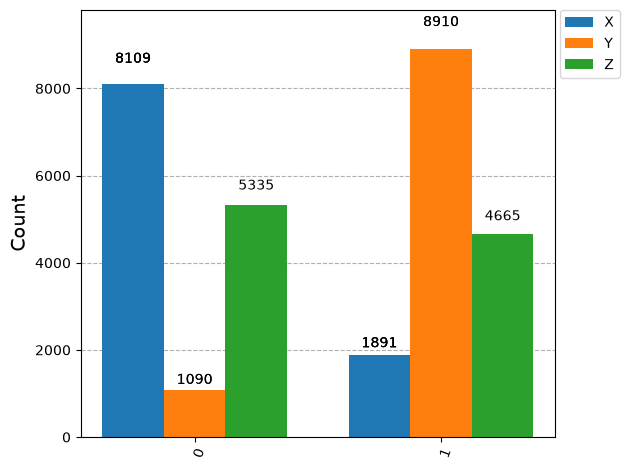

In [11]:
from qiskit.result import marginal_counts
from qiskit.visualization import plot_histogram
from IPython.display import display

# Keep only the bit associated with the final measurement of q[4].
mx = marginal_counts(counts_x, indices=[out_x])
my = marginal_counts(counts_y, indices=[out_y])
mz = marginal_counts(counts_z, indices=[out_z])

print("X:", mx)
print("Y:", my)
print("Z:", mz)

# Show only the marginal distributions of the output qubit.
display(plot_histogram(
    [mx, my, mz],
    legend=["X", "Y", "Z"]
))

## Expectation values

For a Pauli measurement $P\in\{X,Y,Z\}$ with outcomes $0$ and $1$,

$$
\langle P\rangle
=
\frac{N_0-N_1}{N_0+N_1}.
$$

The three quantities form the reconstructed Bloch vector

$$
\mathbf r_{\mathrm{meas}}
=
\left(
\langle X\rangle,
\langle Y\rangle,
\langle Z\rangle
\right).
$$

In [12]:
def expectation(counts):
    """Estimate <P> from the binary counts of a Pauli measurement."""

    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)

    return (n0 - n1) / (n0 + n1)


# Measured components of the Bloch vector of q[4].
x_meas = expectation(mx)
y_meas = expectation(my)
z_meas = expectation(mz)

print("<X> measured =", x_meas)
print("<Y> measured =", y_meas)
print("<Z> measured =", z_meas)

<X> measured = 0.6218
<Y> measured = -0.782
<Z> measured = 0.067


## Theoretical reference state

The theoretical reference is constructed independently of the MBQC circuit. On a single qubit, we prepare the same input state and directly apply

$$
U_R(\xi,\eta,\zeta)
=
R_x(\zeta)R_z(\eta)R_x(\xi).
$$

The target is therefore

$$
|\psi_{\mathrm{target}}\rangle
=
R_x(\zeta)R_z(\eta)R_x(\xi)
R_z(\phi)R_y(\theta)|0\rangle.
$$

Its Bloch vector should agree with the one obtained from the MBQC circuit, within the statistical uncertainty due to finite shots.

In [13]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, Statevector

# Reference circuit in the standard gate model.
reference = QuantumCircuit(1)

# Prepare |psi_in>.
reference.ry(theta_value, 0)
reference.rz(phi_value, 0)

# Apply U_R = Rx(zeta) Rz(eta) Rx(xi).
# The chronological order of the calls is xi -> eta -> zeta.
reference.rx(xi_value, 0)
reference.rz(eta_value, 0)
reference.rx(zeta_value, 0)

psi_theory = Statevector.from_instruction(reference)

# Theoretical values of the three Pauli observables.
x_theory = float(np.real(psi_theory.expectation_value(Pauli("X"))))
y_theory = float(np.real(psi_theory.expectation_value(Pauli("Y"))))
z_theory = float(np.real(psi_theory.expectation_value(Pauli("Z"))))

print("<X> theoretical =", x_theory)
print("<Y> theoretical =", y_theory)
print("<Z> theoretical =", z_theory)

<X> theoretical = 0.6099577937907781
<Y> theoretical = -0.7902967457439002
<Z> theoretical = 0.058159637726587554


## Numerical comparison

The observed differences should be consistent with statistical fluctuations due to the finite number of shots.

For a theoretical probability $p$, the frequency estimated from $N$ runs has standard deviation

$$
\sigma_{\hat p}=\sqrt{\frac{p(1-p)}{N}}.
$$

With $N=10^4$ shots, the uncertainty is largest at $p=0.5$:

$$
\sigma_{\max}
=
\sqrt{\frac{0.25}{10^4}}
=
5\times10^{-3}.
$$

Therefore, differences of order $10^{-2}$ are consistent with ordinary statistical fluctuations from finite sampling. Agreement within a few $10^{-2}$, or better, is reasonable for $10^4$ shots per basis.

In [14]:
# Component-by-component comparison.
print("       measured          theoretical             |error|")
print(f"<X>   {x_meas: .6f}     {x_theory: .6f}     {abs(x_meas - x_theory):.6f}")
print(f"<Y>   {y_meas: .6f}     {y_theory: .6f}     {abs(y_meas - y_theory):.6f}")
print(f"<Z>   {z_meas: .6f}     {z_theory: .6f}     {abs(z_meas - z_theory):.6f}")

       measured          theoretical             |error|
<X>    0.621800      0.609958     0.011842
<Y>   -0.782000     -0.790297     0.008297
<Z>    0.067000      0.058160     0.008840


## Fidelity

For a pure target with Bloch vector $\mathbf r_{\mathrm{th}}$ and a reconstructed state with vector $\mathbf r_{\mathrm{meas}}$,

$$
F
=
\frac{1+\mathbf r_{\mathrm{th}}\cdot\mathbf r_{\mathrm{meas}}}{2}.
$$

Statistical fluctuations can make the norm of the reconstructed vector slightly larger than $1$; in that case, it is projected back onto the Bloch sphere before the calculation.

In [15]:
# Measured Bloch vector.
r_meas = np.array([x_meas, y_meas, z_meas], dtype=float)

# Apply a small numerical correction only if the estimate lies outside the sphere.
norm = np.linalg.norm(r_meas)
if norm > 1:
    r_meas = r_meas / norm

# Bloch vector of the pure target.
r_theory = np.array([x_theory, y_theory, z_theory], dtype=float)

# Fidelity between the pure target and the reconstructed state.
fidelity = (1 + np.dot(r_theory, r_meas)) / 2

print("Fidelity =", fidelity)

Fidelity = 0.9999287255967311


Unit fidelity confirms that the obtained state matches the theoretically expected state.

If the adaptive bases and corrections are implemented correctly, qubit $q_4$ holds

$$
\boxed{
|\psi_{\mathrm{out}}\rangle
=
U_R(\xi,\eta,\zeta)|\psi_{\mathrm{in}}\rangle
}.
$$

The rotation in the MBQC circuit emerges from the sequence of adaptive measurements on the cluster, while the quantum information is teleported from $q_0$ to $q_4$.

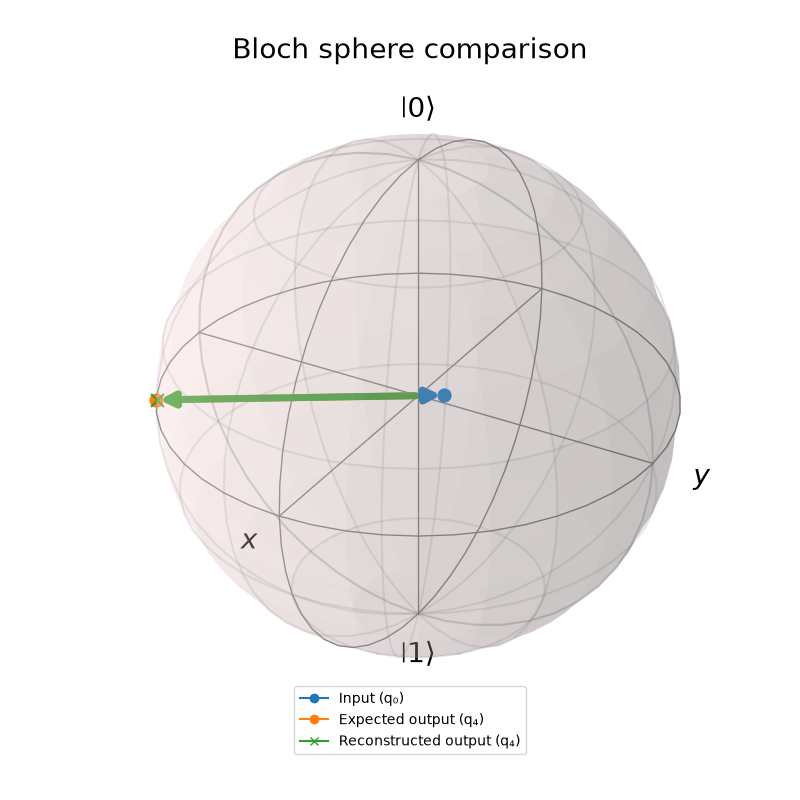

In [16]:
# Restart the kernel after installing ipympl for the first time.
# Drag to rotate the sphere; use the toolbar to zoom.
try:
    from google.colab import output
except ImportError:
    pass
else:
    output.enable_custom_widget_manager()

%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from qiskit.visualization.bloch import Bloch


class BlochComparison:
    """Compare the input and outputs on an interactive Bloch sphere."""

    def __init__(self, r_input, r_expected, r_obtained):
        self.states = [
            (np.array(r_input, dtype=float, copy=True),
             "Input (q₀)", "tab:blue", "o"),
            (np.array(r_expected, dtype=float, copy=True),
             "Expected output (q₄)", "tab:orange", "o"),
            (np.array(r_obtained, dtype=float, copy=True),
             "Reconstructed output (q₄)", "tab:green", "x"),
        ]
        self.fig = plt.figure(figsize=(8, 8))
        self.ax = self.fig.add_subplot(111, projection="3d")
        self.bloch = Bloch(fig=self.fig, axes=self.ax)
        self._draw()

    def _draw(self):
        self.bloch.vector_color = [color for _, _, color, _ in self.states]
        self.bloch.add_vectors([r for r, _, _, _ in self.states])
        self.bloch.render(title="Bloch sphere comparison\n")

        handles = []
        for r, label, color, marker in self.states:
            # Bloch uses plotting coordinates (y, -x, z).
            # Different markers distinguish the nearly overlapping outputs.
            self.ax.scatter(r[1], -r[0], r[2], color=color, marker=marker,
                            s=85, depthshade=False)
            handles.append(Line2D([0], [0], color=color, marker=marker,
                                  label=label))
        self.ax.legend(handles=handles, loc="lower center",
                       bbox_to_anchor=(0.5, -0.08))

    def show(self):
        """Display the figure with the widget backend's interactive controls."""
        plt.show()


# Initial state Rz(phi) Ry(theta) |0>, before the rotation U_R.
r_input = np.array([
    np.sin(theta_value) * np.cos(phi_value),
    np.sin(theta_value) * np.sin(phi_value),
    np.cos(theta_value),
])

# r_meas includes the norm correction described in the fidelity cell.
bloch_comparison = BlochComparison(r_input, r_theory, r_meas)
bloch_comparison.show()
